<h1 style="color:teal; font-size:45px; font-family:'Verdana', sans-serif; font-weight:bold; margin-bottom: 5px;">
Rapport - Projet HDDL
</h1>

<p style="color:#444; font-size:12px; font-family:'Verdana', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Dataset - The Oxford-IIIT Pet Dataset 
</p>
<p style="font-size:16px; font-family:'Verdana'; color:#34495e; margin-top: 0px; text-align: right;">
EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume
</p>

<div style="margin-top: 100px;">
</div>
<div style="border-left: 6px solid #2980b9; background-color: #f0f8ff; padding: 15px; margin: 20px 0; font-family:Verdana; font-size:16px;">
<h2 style="color:#2980b9; ">Sommaire</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li><a href="#chap0" style="color:#2c3e50; text-decoration: none;"><strong>0. Librairies</strong></a></li>
    <li><a href="#chap1" style="color:#2c3e50; text-decoration: none;"><strong>1. </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#dupl" style="color:#2c3e50; text-decoration: none;">1.1 </a></li>
        <li><a href="#red" style="color:#2c3e50; text-decoration: none;">1.2 </a></li>
        <li><a href="#trans" style="color:#2c3e50; text-decoration: none;">1.3 </a></li>
    </ul>
    <li><a href="#chap2" style="color:#2c3e50; text-decoration: none;"><strong>2. </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
        <li><a href="#22" style="color:#2c3e50; text-decoration: none;">2.2 </a></li>
    </ul>
<li><a href="#chap3" style="color:#2c3e50; text-decoration: none;"><strong>3. </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#31" style="color:#2c3e50; text-decoration: none;">3.1 </a></li>
        <li><a href="#32" style="color:#2c3e50; text-decoration: none;">3.2 </a></li>
        <li><a href="#33" style="color:#2c3e50; text-decoration: none;">3.3 </a></li>
        <li><a href="#34" style="color:#2c3e50; text-decoration: none;">3.4 </a></li>
        <li><a href="#35" style="color:#2c3e50; text-decoration: none;">3.5 </a></li>
        <li><a href="#36" style="color:#2c3e50; text-decoration: none;">3.6 </a></li>
        <li><a href="#37" style="color:#2c3e50; text-decoration: none;">3.7 </a></li>
        <li><a href="#38" style="color:#2c3e50; text-decoration: none;">3.8 </a></li>
        <li><a href="#39" style="color:#2c3e50; text-decoration: none;">3.9 </a></li>
    </ul>
<li><a href="#chap4" style="color:#2c3e50; text-decoration: none;"><strong>4. </strong></a></li>
</ul>
</div>

<div id="chap0"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    0. Librairies
</h2>

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

import random
import pandas
import math
import pandas as pd

# Utils
import os
import shutil
import time
import re

# Maths - Stats
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import random as rd

#torch
import torch
import torch.nn as nn
import torch.optim as optim

import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

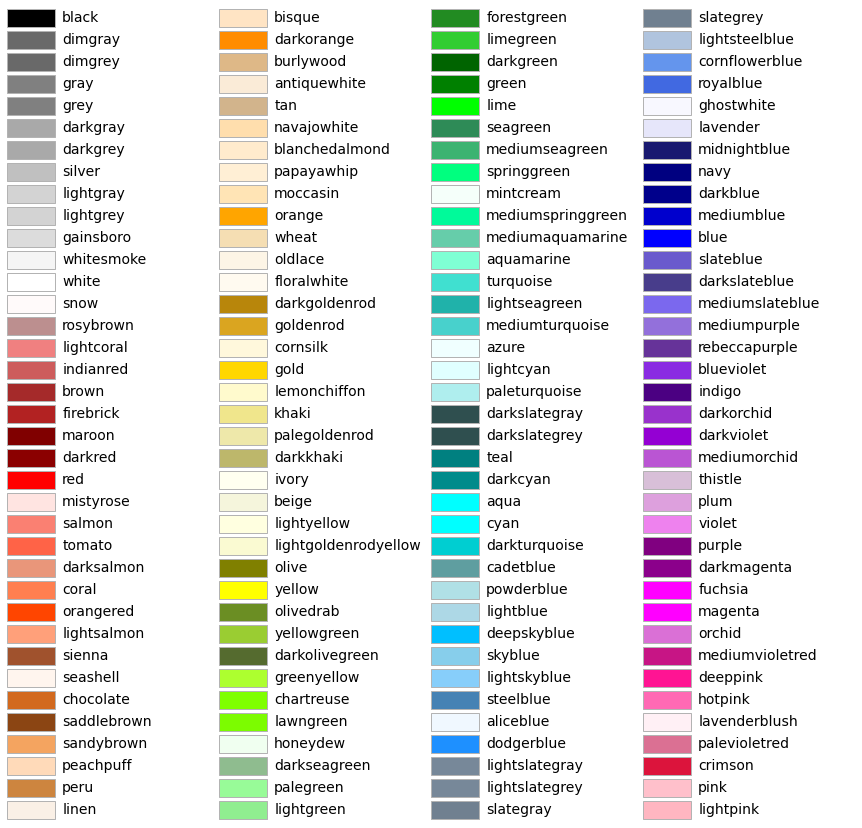

In [3]:
plot_colortable(mcolors.CSS4_COLORS)
plt.show()

# Importation des données

O. M. Parkhi, A. Vedaldi, A. Zisserman, C. V. Jawahar
   Cats and Dogs  
   IEEE Conference on Computer Vision and Pattern Recognition, 2012

Dataset contenant 37 categories d'animaux avec environ 200 images de chaque classe.

trimaps/ 	Trimap annotations for every image in the dataset  
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
- Each entry in the file is of following nature:
- Image CLASS-ID SPECIES BREED ID
- ID: 1:37 Class ids
- SPECIES: 1:Cat 2:Dog
- BREED ID: 1-25:Cat 1:12:Dog
All images with 1st letter as captial are cat images while images with small first letter are dog images.
trainval.txt	Files describing splits used in the paper.However,
test.txt	you are encouraged to try random splits.

(cf readme)


In [4]:
# --- 1. Définition des chemins ---
path = "./oxford-iiit-pet/"
annotations_path = os.path.join(path, "annotations")
images_path = os.path.join(path, "image") 

print(f"Chemin des annotations : {annotations_path}")
print(f"Chemin des images : {images_path}")

# --- 2. Lecture du fichier principal (list.txt) pour les labels ---

list_txt_path = os.path.join(annotations_path, "list.txt")
all_labels_data = []

try:
    with open(list_txt_path, 'r') as f:
        for line in f:
            line = line.strip()
            # Ignorer les lignes vides ou les commentaires (commençant par #)
            if not line or line.startswith('#'):
                continue
            
            # Diviser la ligne en gérant les espaces multiples
            parts = re.split(r'\s+', line)
            
            if len(parts) == 4:
                # Les fichiers d'annotation n'ont pas d'extension, mais les images si.
                image_name = parts[0] + ".jpg" 
                class_id = int(parts[1])
                species = int(parts[2])  # 1:Cat, 2:Dog
                breed_id = int(parts[3])
                
                # Mapper SPECIES (1:Cat, 2:Dog) à category (0:Cat, 1:Dog)
                # pour correspondre à la logique de votre ancien code.
                category = 0 if species == 1 else 1 # 0 pour Chat (Species 1), 1 pour Chien (Species 2)
                
                all_labels_data.append([image_name, class_id, species, breed_id, category])

    # Créer un DataFrame principal avec toutes les informations
    labels_df = pd.DataFrame(
        all_labels_data, 
        columns=['filename', 'CLASS-ID', 'SPECIES', 'BREED ID', 'category']
    )
    
    print(f"\nLabels chargés avec succès depuis list.txt. Total : {len(labels_df)} images.")
    # print(labels_df.head()) # Décommentez pour vérifier

except FileNotFoundError:
    print(f"ERREUR: Le fichier {list_txt_path} n'a pas été trouvé.")
    # Quitter ou gérer l'erreur
    exit()


Chemin des annotations : ./oxford-iiit-pet/annotations
Chemin des images : ./oxford-iiit-pet/image

Labels chargés avec succès depuis list.txt. Total : 7349 images.


In [5]:
# --- 4. Definition des ensembles train, validation et test ---
# 1. Première division : (Train + Validation) et Test
# Nous stratifions sur 'category' pour garder les proportions de chats/chiens
RANDOM_SEED=42

train_val_df, test_df = train_test_split(
    labels_df,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=labels_df['category']
)

# 2. Deuxième division : Train et Validation (à partir du train_val_df)
# Nous re-stratifions pour garantir les proportions dans les deux ensembles
total_train_df, total_validation_df = train_test_split(
    train_val_df,
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=train_val_df['category']
)

# Réinitialiser les index pour un affichage propre et éviter les erreurs de .copy()
total_train_df = total_train_df.reset_index(drop=True).copy()
total_validation_df = total_validation_df.reset_index(drop=True).copy()
test_df = test_df.reset_index(drop=True).copy()

# --- 6. Conversion de la colonne 'category' en string ---

total_train_df['category'] = total_train_df['category'].astype(str)
total_validation_df['category'] = total_validation_df['category'].astype(str)
test_df['category'] = test_df['category'].astype(str)

total_train_df.drop('SPECIES',axis=1,inplace=True)
total_validation_df.drop('SPECIES',axis=1,inplace=True)
test_df.drop('SPECIES',axis=1,inplace=True)

# --- 7. Affichage des résultats ---

print("\n--- Aperçu du DataFrame d'entraînement (total_train_df) ---")
print(total_train_df.head())
print(f"\nDistribution des classes (Train) :\n{total_train_df['category'].value_counts()}")


print("\n--- Aperçu du DataFrame de validation (total_validation_df) ---")
print(total_validation_df.head())
print(f"\nDistribution des classes (Validation) :\n{total_validation_df['category'].value_counts()}")


print("\n--- Aperçu du DataFrame de test (test_df) ---")
print(test_df.head())
print(f"\nDistribution des classes (Test) :\n{test_df['category'].value_counts()}")


--- Aperçu du DataFrame d'entraînement (total_train_df) ---
                    filename  CLASS-ID  BREED ID category
0  British_Shorthair_164.jpg        10         5        0
1       basset_hound_173.jpg         4         3        1
2             Bombay_105.jpg         8         4        0
3     wheaten_terrier_80.jpg        36        24        1
4          pomeranian_26.jpg        25        17        1

Distribution des classes (Train) :
category
1    2787
0    1328
Name: count, dtype: int64

--- Aperçu du DataFrame de validation (total_validation_df) ---
                 filename  CLASS-ID  BREED ID category
0          samoyed_21.jpg        30        20        1
1  wheaten_terrier_19.jpg        36        24        1
2      Maine_Coon_123.jpg        21         7        0
3          Persian_69.jpg        24         8        0
4      Maine_Coon_115.jpg        21         7        0

Distribution des classes (Validation) :
category
1    697
0    332
Name: count, dtype: int64

--- Aperçu

In [6]:
#choisir N_train et N_test tels qu'il soient divisibles facilemetn par la taille de batch

N_train=total_train_df.shape[0]
N_validation=total_validation_df.shape[0]
N_test=test_df.shape[0]


print("Train data: %d images" %(N_train))
print("Validation data: %d images" %(N_validation))
print("Test data: %d images" %(N_test))

Train data: 4115 images
Validation data: 1029 images
Test data: 2205 images


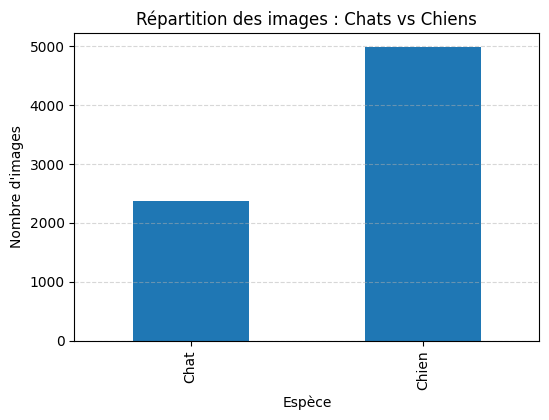

In [7]:
import matplotlib.pyplot as plt

# Comptage par catégorie (0 = chat, 1 = chien)
species_counts = labels_df['category'].value_counts().sort_index()
species_counts.index = ['Chat', 'Chien']

plt.figure(figsize=(6,4))
species_counts.plot(kind='bar')
plt.title("Répartition des images : Chats vs Chiens")
plt.ylabel("Nombre d'images")
plt.xlabel("Espèce")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

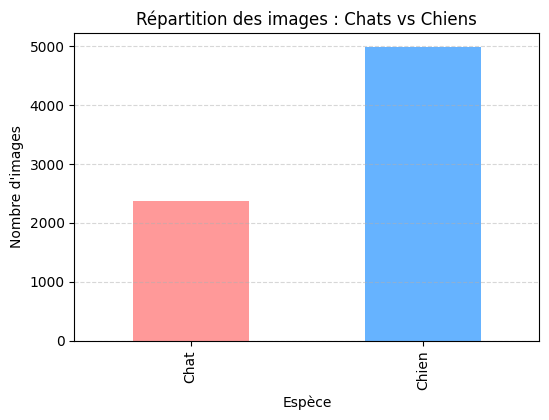

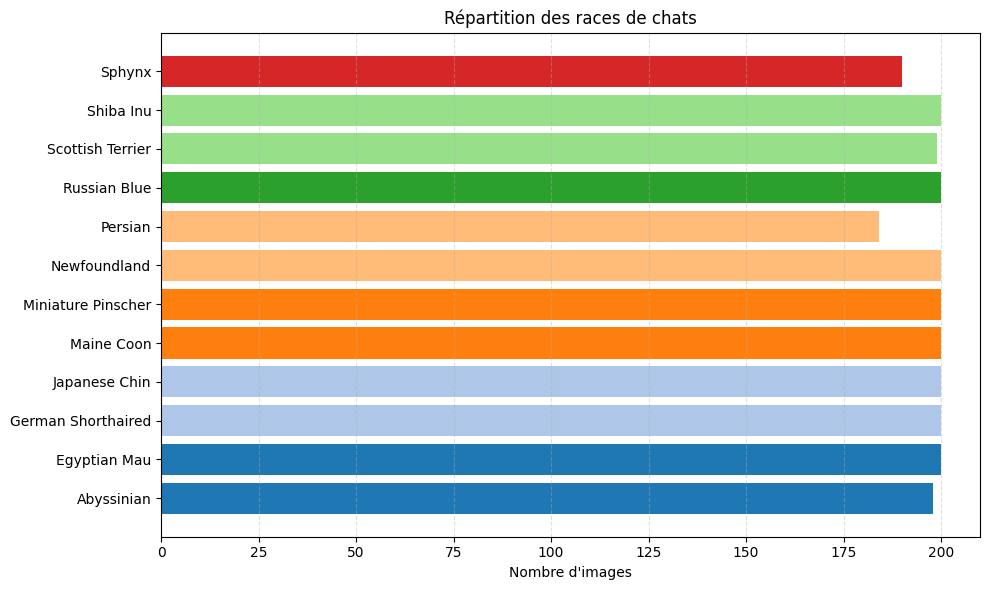

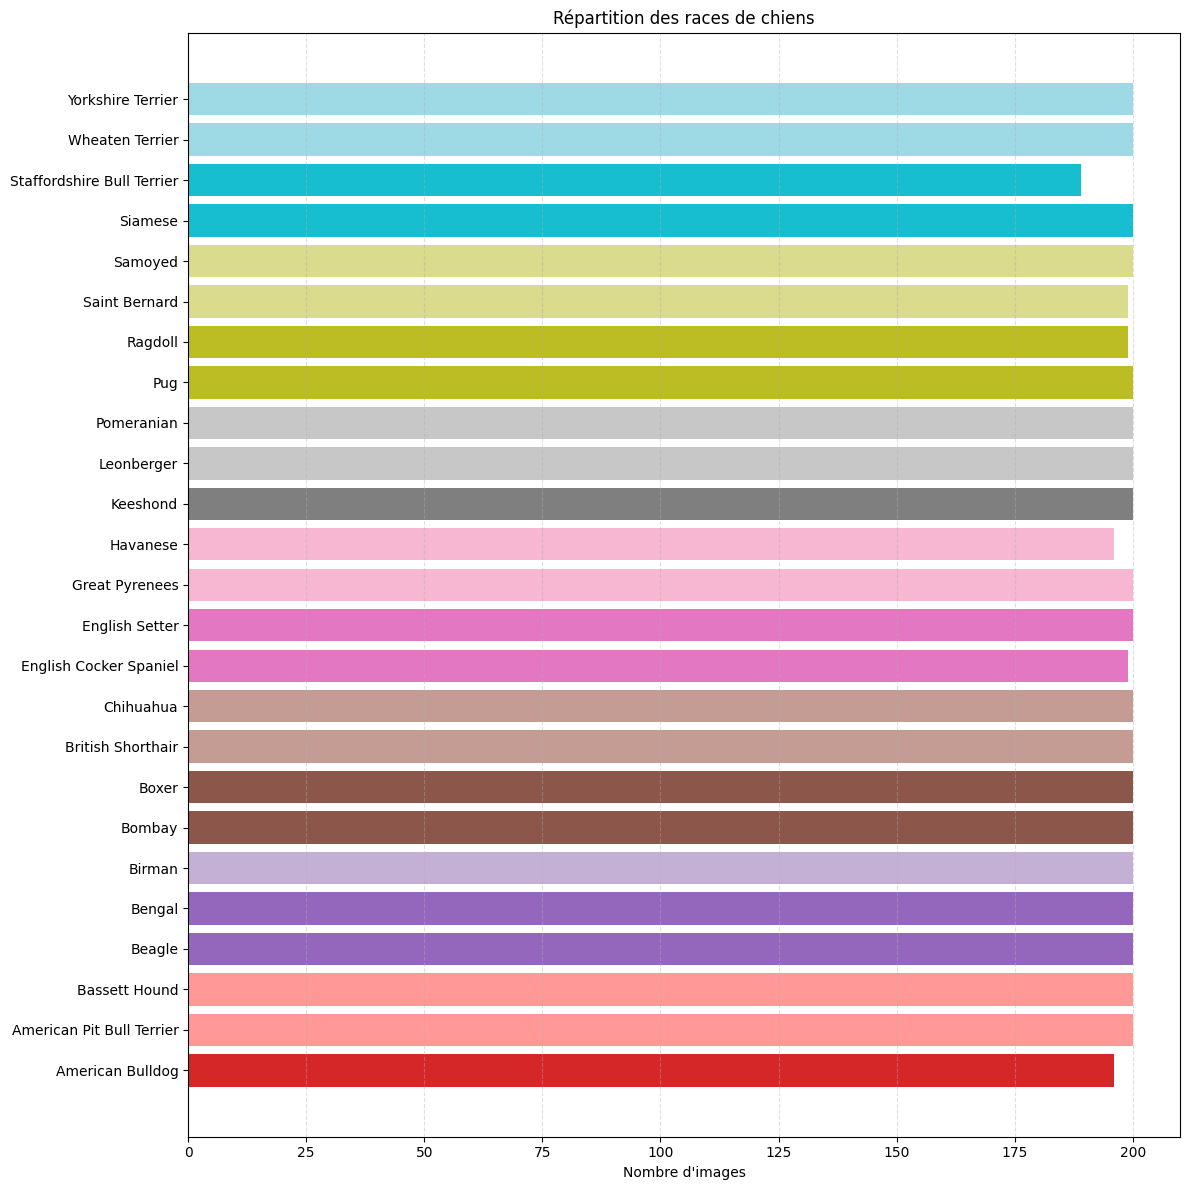

In [13]:
breed_names = [
    # 1–12 : Chats
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx",

    # 13–37 : Chiens
    "American Bulldog", "American Pit Bull Terrier", "Bassett Hound",
    "Beagle", "Boxer", "Chihuahua", "English Cocker Spaniel",
    "English Setter", "German Shorthaired", "Great Pyrenees",
    "Havanese", "Japanese Chin", "Keeshond", "Leonberger",
    "Miniature Pinscher", "Newfoundland", "Pomeranian", "Pug",
    "Saint Bernard", "Samoyed", "Scottish Terrier", "Shiba Inu",
    "Staffordshire Bull Terrier", "Wheaten Terrier", "Yorkshire Terrier"
]

# Ajouter au DataFrame : nom de la race
labels_df["breed_name"] = labels_df["CLASS-ID"].apply(lambda i: breed_names[i - 1])
cat_color = "#ff9999"   # rose/rouge léger
dog_color = "#66b3ff"   # bleu clair

# Palette complète pour les races
import matplotlib.cm as cm
import numpy as np
race_colors = cm.tab20(np.linspace(0, 1, 37))  # 37 couleurs

import matplotlib.pyplot as plt

species_counts = labels_df["category"].value_counts().sort_index()
species_counts.index = ["Chat", "Chien"]
colors = [cat_color, dog_color]

plt.figure(figsize=(6,4))
species_counts.plot(kind="bar", color=colors)
plt.title("Répartition des images : Chats vs Chiens")
plt.ylabel("Nombre d'images")
plt.xlabel("Espèce")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

breed_counts = labels_df["breed_name"].value_counts().sort_index()

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Préparation couleurs
race_colors = cm.tab20(np.linspace(0, 1, 37))  # 37 couleurs

# Chats (1–12)
cat_breeds = labels_df[labels_df["category"] == 0]["breed_name"].value_counts().sort_index()
cat_colors = race_colors[:12]

plt.figure(figsize=(10, 6))
plt.barh(cat_breeds.index, cat_breeds.values, color=cat_colors)
plt.xlabel("Nombre d'images")
plt.title("Répartition des races de chats")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Chiens (13–37)
dog_breeds = labels_df[labels_df["category"] == 1]["breed_name"].value_counts().sort_index()
dog_colors = race_colors[12:]

plt.figure(figsize=(12, 12))
plt.barh(dog_breeds.index, dog_breeds.values, color=dog_colors)
plt.xlabel("Nombre d'images")
plt.title("Répartition des races de chiens")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#!pip install --user opencv-python

   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.3/39.0 MB 2.6 MB/s eta 0:00:15
   -- ------------------------------------- 2.1/39.0 MB 3.1 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/39.0 MB 2.6 MB/s eta 0:00:14
   --- ------------------------------------ 3.4/39.0 MB 2.8 MB/s eta 0:00:13
   ---- ----------------------------------- 3.9/39.0 MB 2.8 MB/s eta 0:00:13
   ----- ---------------------------------- 5.0/39.0 MB 3.1 MB/s eta 0:00:12
   ----- ---------------------------------- 5.2/39.0 MB 3.1 MB/s eta 0:00:12
   ----- ---------------------------------- 5.8/39.0 MB 2.9 MB/s eta 0:00:12
   ------ --------------------------------- 6.6/39.0 MB 2.9 MB/s eta 0:00:12
   ------- -------------------------------- 7.6/39.0 MB 3.0 MB/s eta 0:00:11
   -------- -

Shape : (400, 600)
Valeurs uniques : [1 2 3]


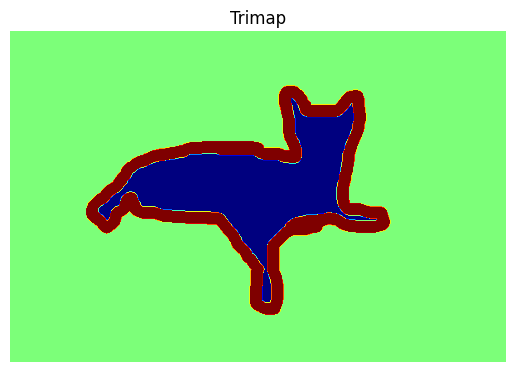

In [23]:
from PIL import Image
import numpy as np
import os

import cv2

trimap_path = "./oxford-iiit-pet/annotations/trimaps/Abyssinian_1.png"

# Charger le trimap directement en 2D
mask = cv2.imread(trimap_path, cv2.IMREAD_UNCHANGED)

print("Shape :", mask.shape)  # devrait être (H, W)
print("Valeurs uniques :", np.unique(mask))

import matplotlib.pyplot as plt

plt.imshow(mask, cmap="jet")
plt.title("Trimap")
plt.axis("off")
plt.show()



In [27]:
image_files = sorted(os.listdir(images_path))
image_files = [f for f in os.listdir(images_path) if f.lower().endswith(".jpg")]
mask_files = sorted(os.listdir(os.path.join(annotations_path, "trimaps")))

# Récupérer les noms sans extension
image_names = [i.replace(".jpg", "") for i in image_files]
mask_names = [m.replace(".png", "") for m in mask_files]

# Filtrer les masques correspondant à des images
mask_for_images = [m for m in mask_names if m in image_names]

print("Nombre de masques correspondant à des images :", len(mask_for_images))


Nombre de masques correspondant à des images : 7390


In [28]:
# Attention très long

from PIL import Image

size_mismatches = []

for img_file in image_files:
    img_name = img_file.replace(".jpg", "")
    mask_file = img_name + ".png"

    img = Image.open(os.path.join(images_path, img_file))
    mask = Image.open(os.path.join(annotations_path, "trimaps", mask_file))

    if img.size != mask.size:
        size_mismatches.append((img_file, img.size, mask.size))

print(f"Problèmes de dimensions : {len(size_mismatches)}")
if size_mismatches:
    for m in size_mismatches[:10]:
        print(m)

Problèmes de dimensions : 0


In [30]:
invalid_mask_values = []

mask_path = os.path.join(annotations_path, "trimaps")

# Filtrer uniquement les vrais fichiers PNG
mask_files = [f for f in os.listdir(mask_path) 
              if f.lower().endswith(".png") and not f.startswith("._")]

print(f"Nombre de masques valides : {len(mask_files)}")

for mask_file in mask_files:
    mask = np.array(Image.open(os.path.join(mask_path, mask_file)))
    unique_vals = np.unique(mask)

    # Le dataset utilise les valeurs 1, 2, 3
    if not set(unique_vals).issubset({1, 2, 3}):
        invalid_mask_values.append((mask_file, unique_vals))

print(f"Masques avec valeurs incorrectes : {len(invalid_mask_values)}")
if invalid_mask_values:
    for m in invalid_mask_values[:5]:
        print(m)

Nombre de masques valides : 7390
Masques avec valeurs incorrectes : 0


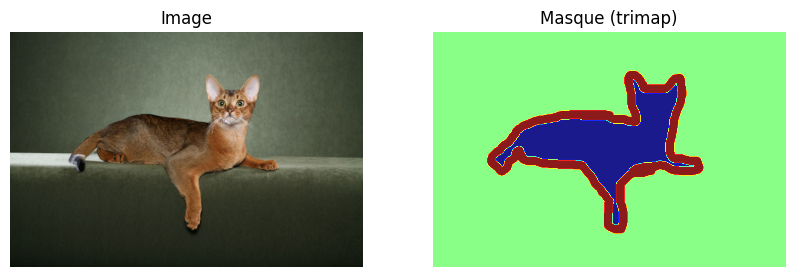

In [31]:
def show_image_with_mask(image_name):
    img_path = os.path.join(images_path, image_name + ".jpg")
    mask_path = os.path.join(annotations_path, "trimaps", image_name + ".png")

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    plt.figure(figsize=(10,5))

    # Afficher image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    # Afficher masque (couleurs distinctes)
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="jet", alpha=0.9)
    plt.title("Masque (trimap)")
    plt.axis("off")

    plt.show()


# Exemple :
show_image_with_mask("Abyssinian_1")


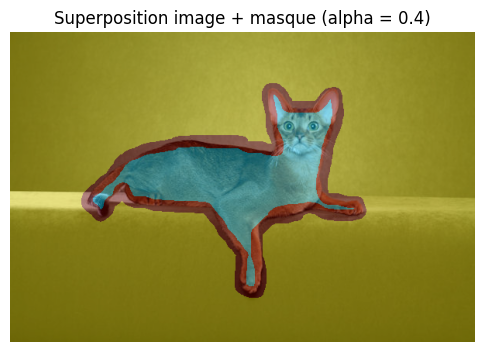

In [32]:
def show_overlay(image_name):
    img_path = os.path.join(images_path, image_name + ".jpg")
    mask_path = os.path.join(annotations_path, "trimaps", image_name + ".png")

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    # Créer un overlay coloré
    cmap = plt.get_cmap("jet")
    mask_color = cmap(mask / mask.max())[..., :3]  # ignore alpha

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(mask_color, alpha=0.4)
    plt.title("Superposition image + masque (alpha = 0.4)")
    plt.axis("off")
    plt.show()

# Exemple :
show_overlay("Abyssinian_1")


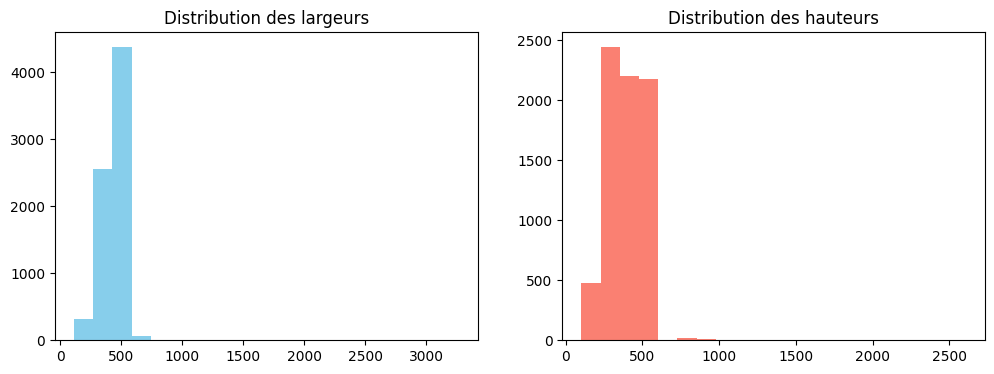

In [34]:
widths, heights = [], []

for img_file in labels_df['filename']:  # tester sur un échantillon si dataset lourd
    img_path = os.path.join(images_path, img_file)
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='skyblue')
plt.title("Distribution des largeurs")
plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='salmon')
plt.title("Distribution des hauteurs")
plt.show()